# Country Segmentation using K-Means Clustering

## About the Project

This project applies K-Means Clustering to group countries based on various socio-economic and health-related indicators. The objective is to identify countries with similar characteristics and understand patterns in development, income, and quality of life.

The project uses data preprocessing, feature scaling, the Elbow Method, and cluster analysis to create meaningful country segments.

In [34]:
#importing required libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [35]:
#loading dataset
df=pd.read_csv('Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [36]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [37]:
X=df.drop(columns='country')

In [38]:
#Feature Scaling
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [39]:
#Elbow Method
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

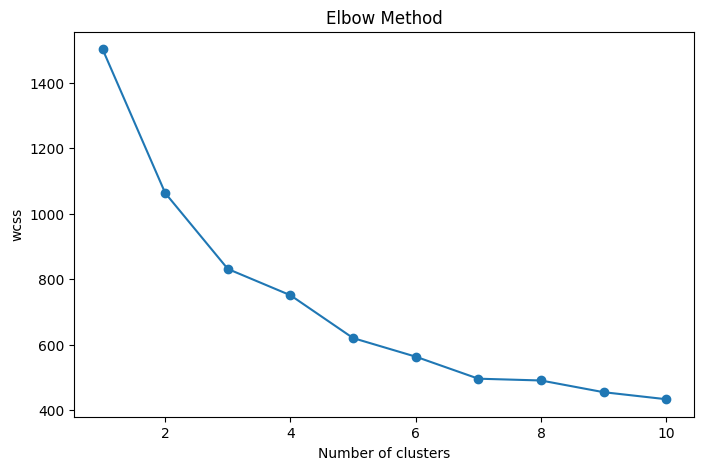

In [40]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('wcss')
plt.show()

In [41]:
#K-means clustering
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)

In [42]:
y_kmeans=kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

In [43]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

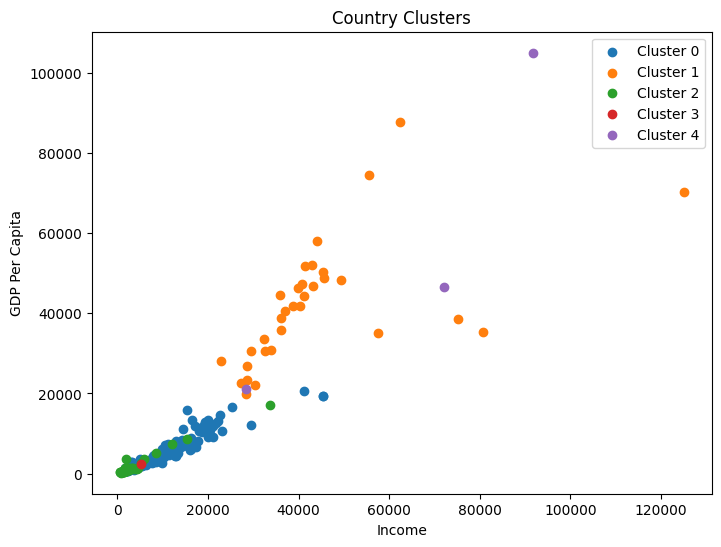


Cluster 0
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Cambodia', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Georgia', 'Grenada', 'Guatemala', 'Guyana', 'Hungary', 'India', 'Indonesia', 'Iran', 'Iraq', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kyrgyz Republic', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Montenegro', 'Morocco', 'Myanmar', 'Nepal', 'Oman', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Romania', 'Russia', 'Samoa', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Slovak Republic', 'Solomon Islands', 'Sri Lanka', 'St. Vincent and the Grenadines', 'Suriname', 'Tajikistan', 'Thailand', 'Tonga', 'Tuni

In [52]:
#Cluster Visualization
plt.figure(figsize=(8,6))
for i in range(5):
  plt.scatter(
    df[df['Cluster']==i]['income'],
    df[df['Cluster']==i]['gdpp'],
    label=f'Cluster {i}'
)


plt.xlabel('Income')
plt.ylabel('GDP Per Capita')
plt.title('Country Clusters')
plt.legend()
plt.show()
for i in range(5):
    print(f"\nCluster {i}")
    print(df[df['Cluster']==i]['country'].tolist())

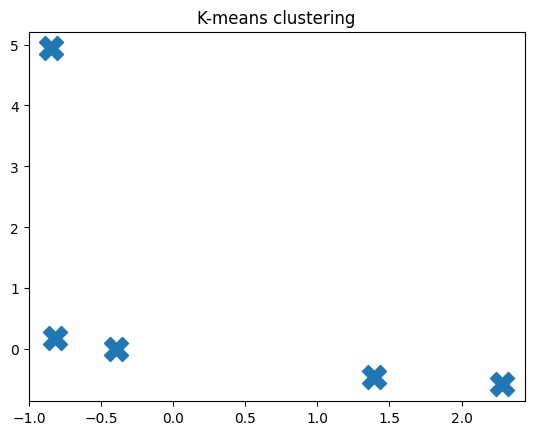

In [45]:
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,marker='X',label='Centroids')
plt.title('K-means clustering')
plt.show()

In [46]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

         child_mort     exports    health     imports        income  \
Cluster                                                               
0         22.219540   41.083782  6.246667   47.795010  12678.965517   
1          5.181250   46.118750  9.088437   40.584375  44021.875000   
2         94.313636   28.677500  6.329091   42.872727   3503.250000   
3        130.000000   25.300000  5.070000   17.400000   5150.000000   
4          4.133333  176.000000  6.793333  156.666667  64033.333333   

          inflation  life_expec  total_fer          gdpp  
Cluster                                                   
0          7.727747   72.625287   2.333333   6494.390805  
1          2.513844   80.081250   1.788437  42118.750000  
2          9.895568   59.022727   5.047727   1753.909091  
3        104.000000   60.500000   5.840000   2330.000000  
4          2.468000   81.433333   1.380000  57566.666667  


In [47]:
from sklearn.metrics import silhouette_score
silhouette_score(X_scaled,y_kmeans)

np.float64(0.30088229124112015)

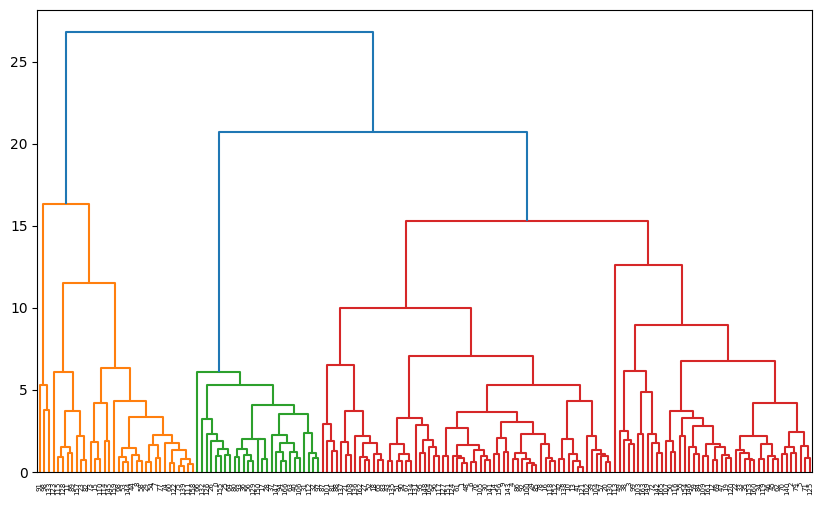

In [48]:
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering
plt.figure(figsize=(10,6))
dendrogram(linkage(X_scaled,method='ward'))
plt.show()

In [49]:
hc=AgglomerativeClustering(n_clusters=5,linkage='ward')
y_hc=hc.fit_predict(X_scaled)
print('HC Silhouette score = ',silhouette_score(X_scaled,y_hc))

HC Silhouette score =  0.2193301598939687


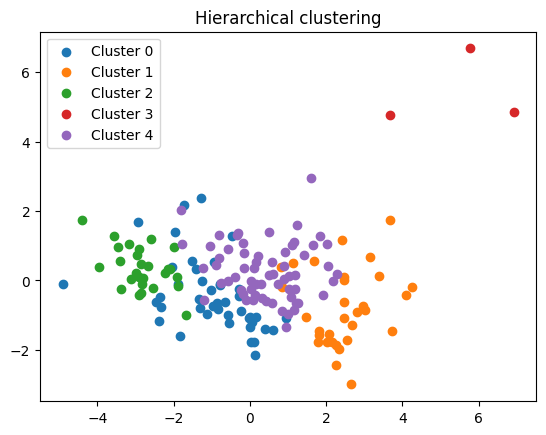

In [50]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)
for i in range(5):
  plt.scatter(X_pca[y_hc==i,0],X_pca[y_hc==i,1],label=f'Cluster {i}')
plt.title('Hierarchical clustering')
plt.legend()
plt.show()
